In [1]:
#Preliminary eyeing of raw data and inferences from it
# Total Records = 1338
# Age - Ranges between 18 to 64 [Minimum Age Count = 69, Maximum Age Count = 22]
# Sex - Male or Female [Female:662, Male:676] : almost eaualrepresentation of data from two genders
# BMI - Ranges between 15.96 to 53.13 [Minimim BMI count:1, Maximum BMI count:1]
# Children -Ranges between 0 to 5 [0:575, 5:19] : Why so many insurers with 0 kids? Few low age bracket could have 0 kids but not so many
# Smoker - Yes or No [Yes: 274 No:1064]
# Regions - SouthEast, SouthWest, NorthEast and NorthWest[SouthEast:364,SouthWest:325,NorthEast:324,NorthWest:325]
# Charges - Minimum 1121.8739 to 63770.42801

# Numerical Columns - Age, BMI, Children, Charges
# Categorical COlumns - Sex, Smoker, Region
# Target Column : Charges( trying to work out insurance charges based on characteristics of the insurer)


# Both the genders have almost equal representation
# About 40% insuree have no kids, Is it error or most of insurees with no kids go for insurance?
# About 80% of insurees are non-smokers. More people with healthy habits go for insurance?
# All the regions have almost equal representation in this data : Is the population density in all regions same?
# Is some region over or under represented. Should we go for region wise analysis?

In [2]:
#Steps and Tasks 1.
import numpy as np
import pandas as pd
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

In [3]:
#Steps and Tasks 2.
insurance_df = pd.read_csv("insurance.csv")

In [4]:
#Steps and Tasks 3a.
insurance_df.shape
#observation: 1338 rows and 7 columns

(1338, 7)

In [5]:
#Steps and Tasks 3b.
insurance_df.dtypes
#Observation2 : 3 columns are categorical types and 4 columns are numeric type

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [6]:
insurance_df.info()
#Observation : Data has float, int and Object values and no column has null or missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
age         1338 non-null int64
sex         1338 non-null object
bmi         1338 non-null float64
children    1338 non-null int64
smoker      1338 non-null object
region      1338 non-null object
charges     1338 non-null float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.2+ KB


In [7]:
insurance_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
insurance_df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [9]:
#observations 3. Charges are dependent variable
#             4. Total 6 Independent variables

In [10]:
#Steps and Tasks 3c.
# For categorical and for numeric values
#Checking presence of missing values
print(insurance_df.isnull().sum())

#As seen here, there are no missing values in any column

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [11]:
#Steps and Tasks 3d.
#5 point summary of numerical attributes
insurance_df.describe().T
#5 numbers that help in knowing the center, spread and shape are Xsmallest, First Quartile(Q1 25%),Median (Q2 50%), 
# Third Quartile (Q3 75%) and Xlargest . All these numbers can be seen using describe()

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [12]:
# Observatiosn 5
# All columns except columns with categorical variables i.e. 'sex','smoker' and 'region' are described
# Age : Mean and median overlapping , Max-Q3= approx 13 units, Q1-Min = approx 9 units, So right tail is slightly longer
# BMI : Mean and median overlapping, Max-Q3 = approx 19 units, Q1-Min = approx 10 units, So right tail is little longer
# Children : Should be treated as categorical variable so not drawing inference

#Charges : Mean > Median , Max-Q3 =47131 and Q1-Min= 3619 Right tail is very long indicating right skew and presence of
#many outliers

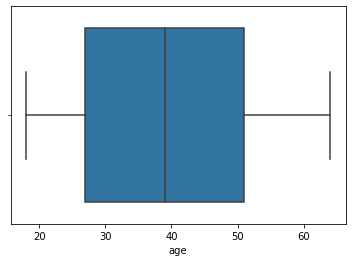

In [13]:
#Drawing Box plot can lead to better visualization of 5 point summary
# Stepas and Tasks 5g - Checking presence of outliers in age, bmi and charges 
sns.boxplot(x=insurance_df['age'])
#Age :The observation from boxplot is matching with what we have inferred from describe() function
#The distribution is nearly normal. Right tail is little longer. No outliers

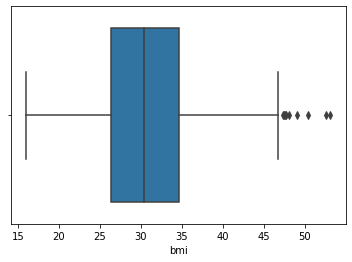

In [14]:
sns.boxplot(x=insurance_df['bmi'])
#The observation from boxplot is matching with what we have inferred from describe() function
#The distribution is normal. Right tail is little longer and there are outliers towards right side which
# need to be investigated 

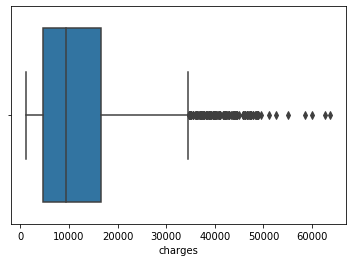

In [15]:
sns.boxplot(x=insurance_df['charges'])
#The observation from boxplot is matching with what we have inferred from describe() function
#Q2-Q1<Q3-Q1 due to right skewedness and many outliers towards right side  

# Steps and Tasks 3e
# Distribution of 'bmi','age','charges'


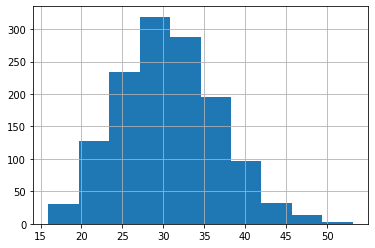

In [16]:
#Histogram showing distribution of BMI
insurance_df['bmi'].hist()

#bmi : has normal distribution with highest peak(maximum frequency)for bmi between 27.5 to 31.
#In USA,as per www.cdc.gov, average BMI of adult man is 26.6 and average adult woman has BMI of 26.5.ideally it should be
# 18.5 to 24.9
# The distribution indicates that more data points have higher bmi value so more people with higher BMI opting for insurance.

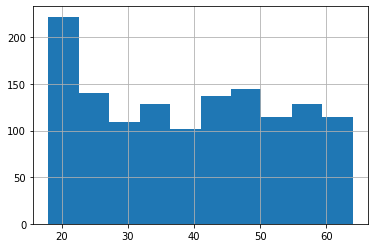

In [17]:
#Histogram showing distribution of age
insurance_df['age'].hist()

#Age : Maximum insurees are in age group between 18 to 22 (Could be due to people starting earning at this age). 
# From 22 to 64 age group insuree count ranges between 100 to 130. Distribution is normal

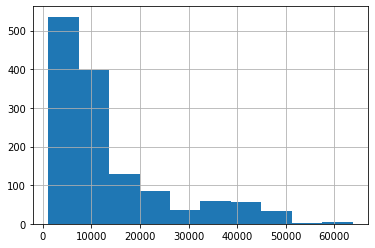

In [18]:
#Histogram showing distribution of charges
insurance_df['charges'].hist()

# Charges:  it is evident that most of the medicalcharges billed by insurance company are between 2000 to 12000 with
# maximum being between 2000 to 6000 (Could be some routine low expense medical treatments)There is a long tail
#towards 60000 which could be some outlier , should be identified and investigated. Distribution is not normal


In [19]:
# Steps and Tasks 3f
# Measure of skewness of ‘bmi’, ‘age’ and ‘charges’  columns 
# skewness along the index axis 
insurance_df[['bmi','age','charges']].skew(axis = 0, skipna = True) 

bmi        0.284047
age        0.055673
charges    1.515880
dtype: float64

In [20]:
#Inference Skewness
# age and bmi :skewness = 0 ,age and bmi have almost 0 skewness so it is normal distribution. If we check their mean and median,these
# are also almost equal which indicates almost negligible skewness
# skewness > 0 : Charges column has asymmetry in distribution . Tail is larger towards right hand side of distribution. 
# Mean is greater than median indicating skewness

In [21]:
# Steps and Tasks 3g
# Checking the presence of outliers in ‘bmi’, ‘age’ and  ‘charges columns
# We had visualized outliers through boxplot. The outliers are present in bmi and charges column. Here we will verify it
# numerically as well. Box plot uses 1.5*IQR as outlier condition so we will here use zscore method and zscore>3 indicates the
# value is 3 standard deviations away from mean which indicates the value is outlier
# BMI
print(insurance_df[stats.zscore(insurance_df[['bmi']]) > 3])
# bmi above 49 is considered as outlier (as seen in corresponding histogram, tail also starts from there) 
# total 4 outliers having bmi 49.06, 50.38, 52.58 and 53.13 have been identified
# Observations:
# > All the 4 outliers are from southeast region
# > All the 4 outliers are males 
# > One outlier is smoker and has exceptionlly high charges (Does high bmi and being smoker lead to more medical conditions?)

      age   sex    bmi  children smoker     region     charges
116    58  male  49.06         0     no  southeast  11381.3254
847    23  male  50.38         1     no  southeast   2438.0552
1047   22  male  52.58         1    yes  southeast  44501.3982
1317   18  male  53.13         0     no  southeast   1163.4627


In [22]:
# zscore outlier identification in age column
print(insurance_df[stats.zscore(insurance_df[['age']]) > 3])
# No outliers found. Boxplot and histogram also lead to same conclusion

Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []


In [23]:
# charges column
print(insurance_df[stats.zscore(insurance_df[['charges']]) > 3].sort_values(by=['charges']))
# 7 outlier points from 51194 and above have been identified. Observation is similar from histogram. However, boxplot
# is considering anything above 35000 as outlier.
# Observations:
# All smokers are outliers in terms of charges. Seems a valid conclusion that smokers have more medical conditions
# all these outliers have bmi towards higher side (i.e. above median value of bmi)
# the extreme two values of charges are for southeast region

      age     sex     bmi  children smoker     region      charges
34     28    male  36.400         1    yes  southwest  51194.55914
1146   60    male  32.800         0    yes  southwest  52590.82939
819    33  female  35.530         0    yes  northwest  55135.40209
577    31  female  38.095         1    yes  northeast  58571.07448
1230   52    male  34.485         3    yes  northwest  60021.39897
1300   45    male  30.360         0    yes  southeast  62592.87309
543    54  female  47.410         0    yes  southeast  63770.42801


In [24]:
# higher bmi and higher claims are for south east region
# all the smokers have higher medical claims

# so smoking is a negative characteristic vis a vis medical insurers

In [25]:
#3h Distribution of categorical columns (include  children) 
# Categorical variables are sex, smoker, region, children

#Summarize categorical attributes
insurance_df.describe(include='object').T

,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


In [26]:
#GENDER ANALYSIS
#Categorical variables 'sex' frequency check
insurance_df["sex"].value_counts()
#Observation 6 : male and female have almost equal representation in the data set

male      676
female    662
Name: sex, dtype: int64

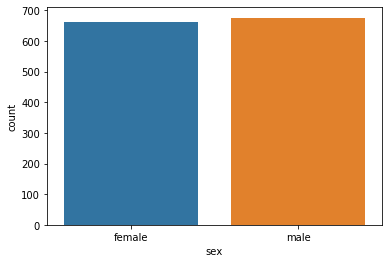

In [27]:
sns.countplot(x='sex', data=insurance_df)

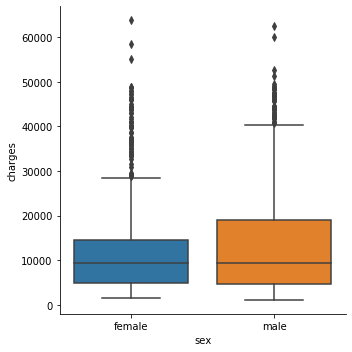

In [28]:
sns.catplot(x="sex", y="charges", kind="box", data=insurance_df);

In [29]:
# Inferences for gender : 
# 1. Both males and females have almost equal representation with males being little more
# 2. Medical claims/chrges for males are little higher than females, though the median values are same

In [30]:
#SMOKER ANALYSIS
#Categorical variables 'smoker' frequency check
insurance_df["smoker"].value_counts()
#Observation 7 : majority of insurees are non smokers

no     1064
yes     274
Name: smoker, dtype: int64

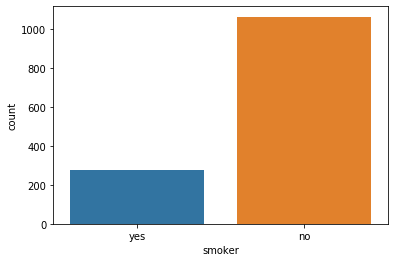

In [31]:
sns.countplot(x='smoker', data=insurance_df)

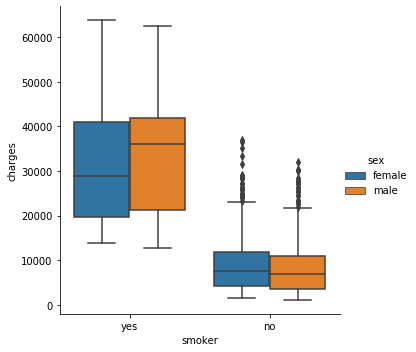

In [32]:
sns.catplot(x="smoker", y="charges", hue='sex', kind="box", data=insurance_df);

In [33]:
#inference:
# Inferences for smoker : 
# 1. Non smokers are 3 times more than smokers (as visualised fom countplot)
# 2. Medical claims/charges for nonsmokers are drastically less than smokers (inspite of non-smokers being 3 times more
# than smokers).The max medical charges billed for non smoker is 10000 and for smoker it is around 40000(almost 4 times)
# 3.Male and female medical bills donot show much difference whether they are smokers and non smokers 

In [34]:
#REGION ANALYSIS
#Categorical variables 'region' frequency check
insurance_df["region"].value_counts()
#Observation 8 : all regions have similar distribution and south east has little high insurers

southeast    364
northwest    325
southwest    325
northeast    324
Name: region, dtype: int64

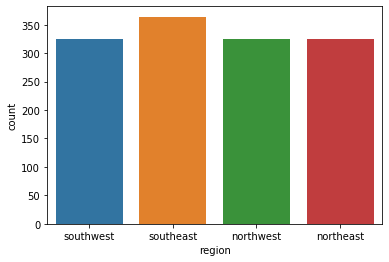

In [35]:
sns.countplot(x='region', data=insurance_df)

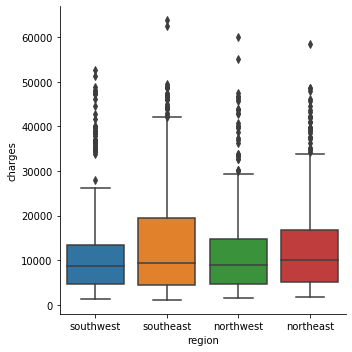

In [36]:
sns.catplot(x="region", y="charges", kind="box", data=insurance_df)

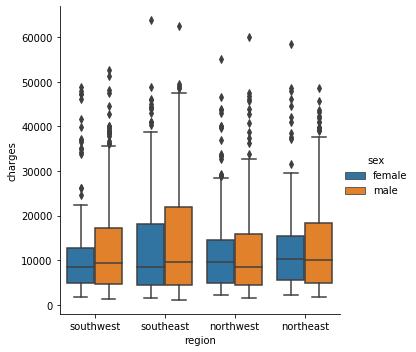

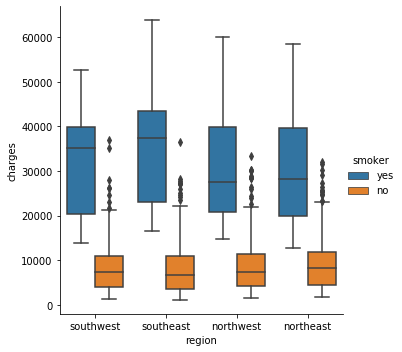

In [37]:
# Inferences for region : 
# 1. Southeast region has little higher representation than other regions as per countplot (Is the population density more
# than rest of the regions need to investigate?)
# 2. median Medical claims/charges for all the regions are almost same. Minimum charges are almost same.Range 
# in  southeast region is maximum . max charges can be sorted as southeast>northeast>northwest>southwest. 
# 3 In spread of charges also southeast >northeast>northwest>southwest. 
# Southeast has maximum datapoints so little more value expected but difference between other regions needs further analysis

sns.catplot(x="region", y="charges", hue= 'sex',kind="box", data=insurance_df);
# Inference: 4 Females show similar distribution, like males, for medicalcharges for various regions

sns.catplot(x="region", y="charges", hue= 'smoker',kind="box", data=insurance_df);
#Inference 5: last plot below shows that non smokers across regions have similar distribution. Smokers in south east region
# have higher charges. Why smokers of south east region have more charges. Are there some other factors along with smoking in south eastern
# region responsible?

In [38]:
# CHILDREN ANALYSIS
#Categorical variables 'children' frequency check
insurance_df["children"].value_counts()

0    574
1    324
2    240
3    157
4     25
5     18
Name: children, dtype: int64

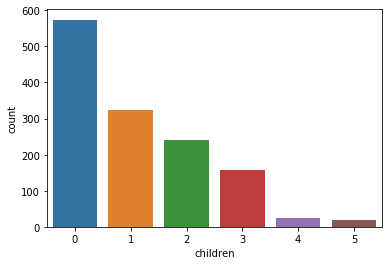

In [39]:
sns.countplot(x='children', data=insurance_df)

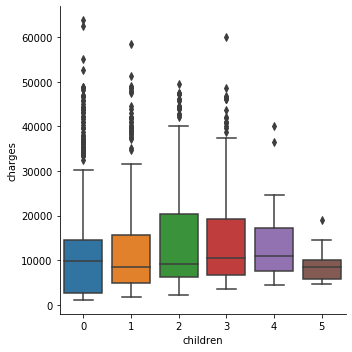

In [40]:
sns.catplot(x="children", y="charges", kind="box", data=insurance_df);

In [41]:
# Inferences for Children : 
# 1. People with 0 children have maximum representation in sample (as is evident from countplot)
# 2. People with 2 children have maximum range and max value is also highest indicating that their medical charges were
# highest. Why people with 5 children have lower range and lower min,max and median values 
# Is it that people with more children are not buying as much insurance

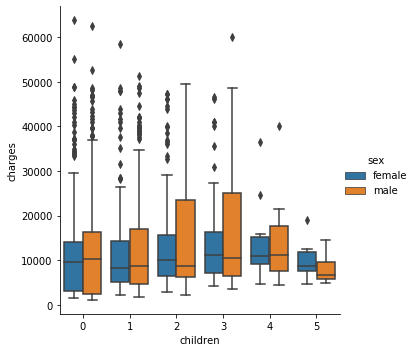

In [42]:
# distribution of charges vis a vis gender and number of children
sns.catplot(x="children", y="charges", hue='sex',kind="box", data=insurance_df);

In [43]:
# Inferences 
# Lot of variation in medical charges paid to male parent with highest being for 3 chidren (though for 2 children
# also almost similar)
# Not much steep variation in medical charges paid to female parent across number of children

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
age                 1338 non-null int64
bmi                 1338 non-null float64
children            1338 non-null int64
charges             1338 non-null float64
sex_male            1338 non-null uint8
smoker_yes          1338 non-null uint8
region_northwest    1338 non-null uint8
region_southeast    1338 non-null uint8
region_southwest    1338 non-null uint8
dtypes: float64(2), int64(2), uint8(5)
memory usage: 48.4 KB


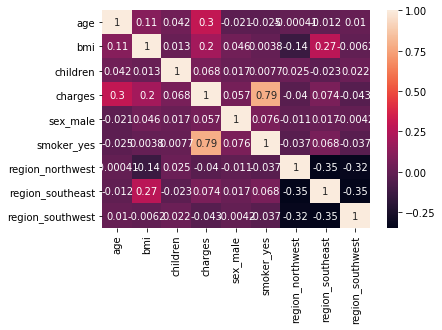

In [44]:
# 3i Pair plot that includes all the columns of the data  frame   
# We will convert categorical variables also into numerical features so that those can be visualized in pairplot
data = pd.get_dummies(insurance_df, drop_first =True)
data.info()
#Find correlation
corr=data.corr()
sns.heatmap(corr, annot=True)
#Observation: Weak correlation between all variables. However, there is strong correlation between smoker and charges

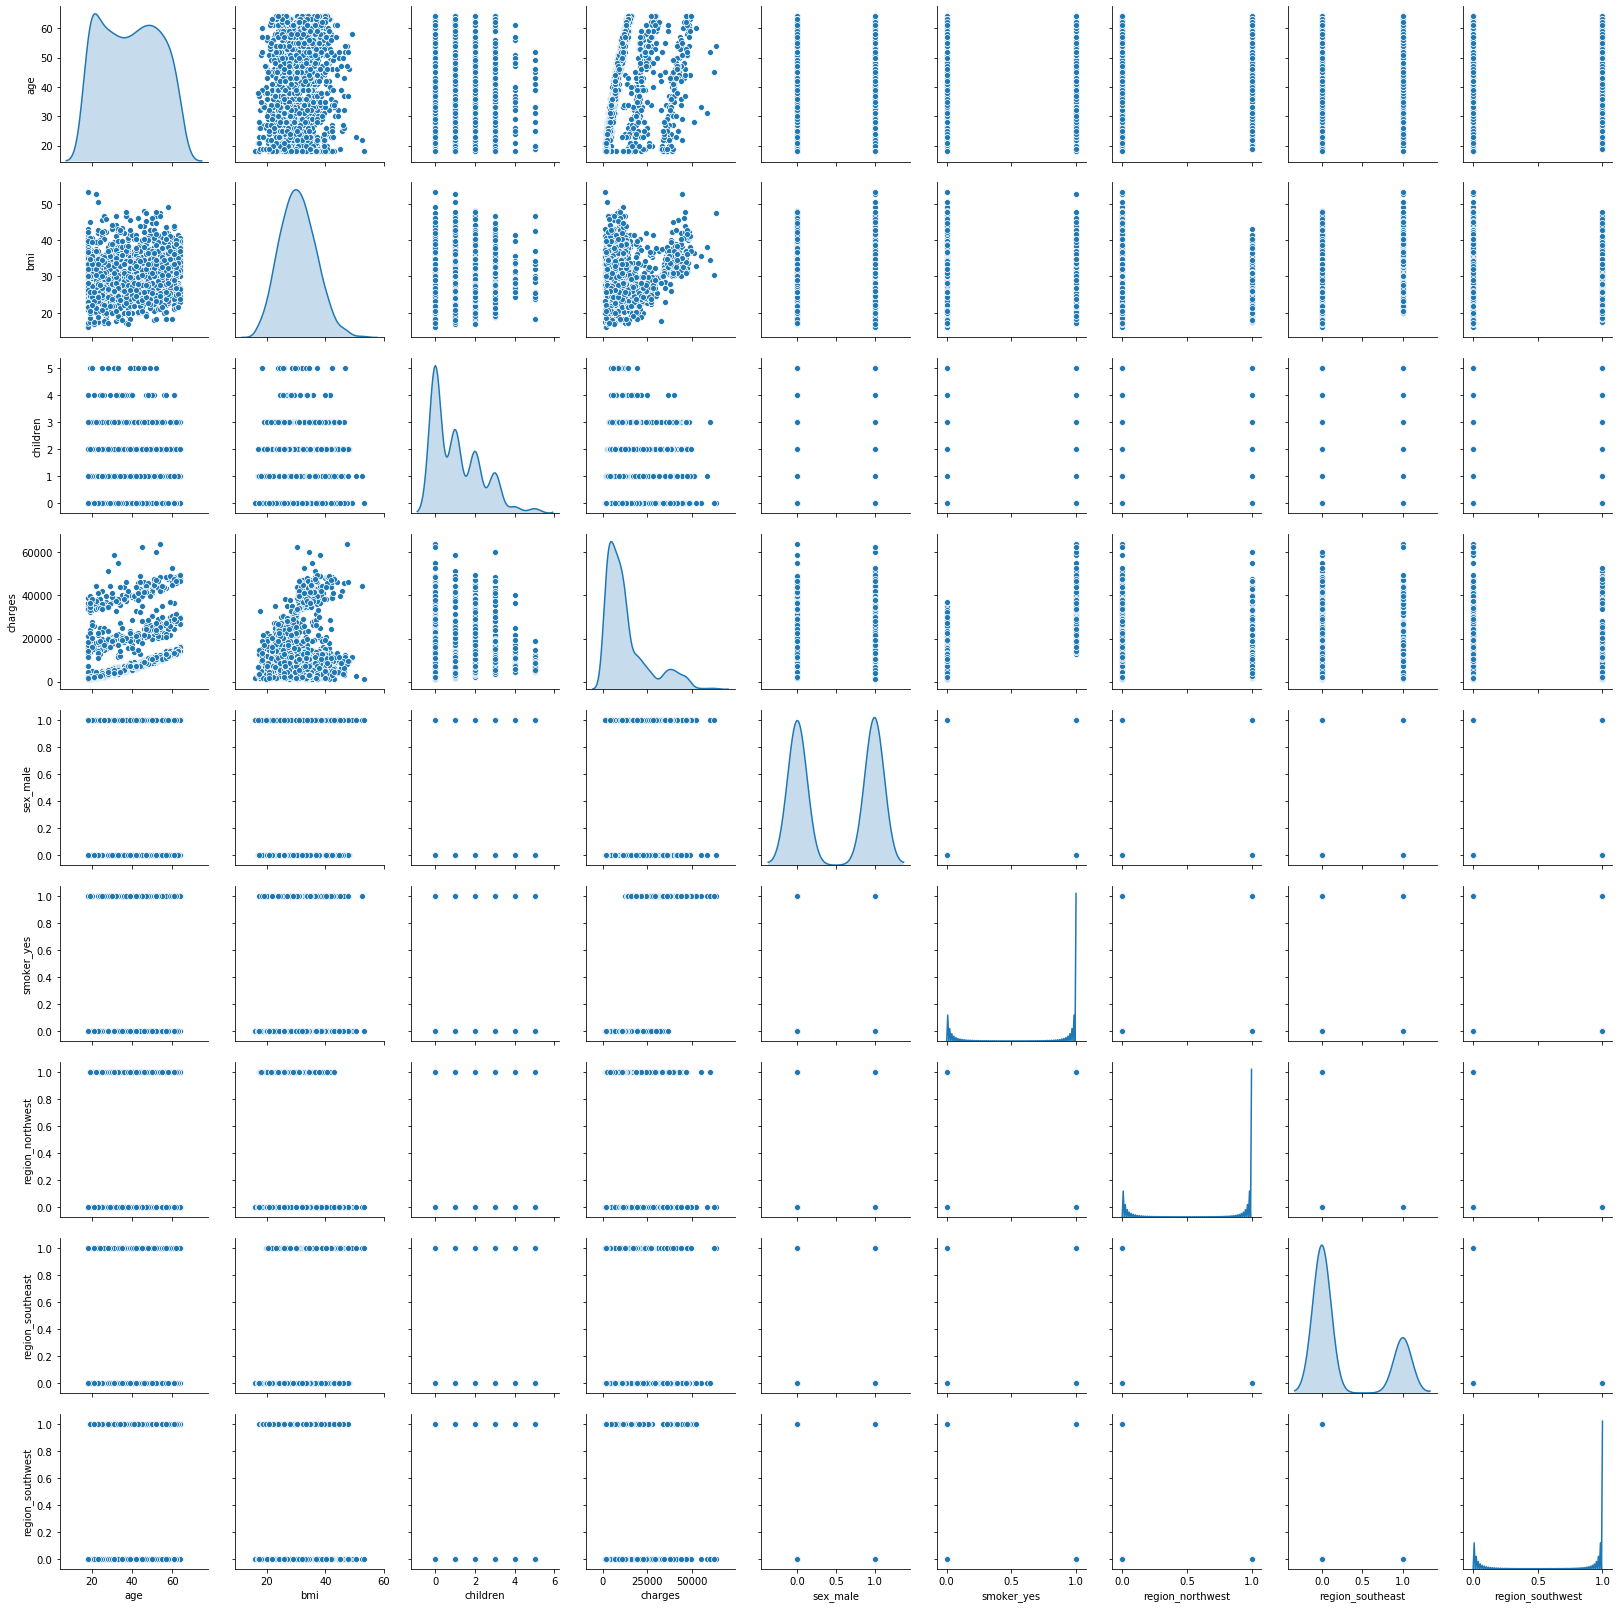

In [45]:
#pairplot shows distribution of various features and also relationship between different features
#sns.pairplot(insurance_df, diag_kind='kde')
sns.pairplot(data, diag_kind='kde')

In [46]:
#Inferences from pair plot
#1 Age 
# a. KDE curve of age is nearly normal with two different peaks indicating two different age groups. There is no tail on
# either side so no outliers exist. The two peaks are between 20to25 and 50to60. Could be because in 20to25 people start
# earning so more insurance buying. Similarly, between 55to60, because of approaching retirement age people start more
# insurance buying
# b. Age and BMI donot have any strong correlation, though there is cloud(representing bmi) moving slightly up with increase in age
# c. Age and Charges show strong positive linear correlation, as age is increasing charges are also increasing
# d: With age smoking habit not changing
# e: All regions showing similar age range

#2 BMI
# a. KDE curve is perfectly normal. There is slight tail towards right hand side indicating presence of
# few outliers towards higher side. 68% buyers have bmi in 25to35 range. In USA,as per www.cdc.gov, average BMI of adult man
# is 26.6 and average adult woman has BMI of 26.5. So the KDE curve indicates that majority of buyers in higher BMI range
# b. bmi shows positive correlation with charges. As bmi is increasing, charges are increasing 
# (though not for all data points)
# Maybe for cases where bmi is increasing along with some other factors, the charges are increasing
# c. BMI for males has wider range from minimum to maximum
# d. BMI for southeast region is towards higher side i.e both minimum and maximum values are more than rest of the regions
#[The doubts which we had why smokers in south east region had more medical charges could be because they had more bmi as well
#? Do people in south east region have poor eating habits or lifestyle??]- check region categorical variable boxplots

#3 Charges
# a. KDE curve has peak aaround 12000 and  has a little spike of charges around 45000
# b. Has a tail towards higher charges, could be due to outliers
# c. Charges and age show positive correlation. As age increases, charges increase. There are many outliers for across age groups
# towards higher charges. The correlation seems to have three different lines of correlation moving like clusters
# d.there seems to be no coorelation between bmi and charges

#4 Children
# a. range and distribution of Count of children is similar across regions, smoking habits, genders.
# b. People with 0 children have maximum medical charges ranging from minimum value to maximum value
# c. People with 5 children have minimum medical charges 
# d. With increase in number of children from 0, 1, 2, 3 ,4 to 5 the charges range and maximum value is decreasing and minimum charge
# value is increasing.
# [Are people with more children not buying medical insurance or people with more children have less stress(hence less diseases)
# and people with 0 children have more stress and hence diseases because of nuclear families in USA]

#5 Gender
# Females have charges distribution similar as males. Though max value is little lower than males. Females have higher outliers
# Males have higher maximum bmi than females


# 6 Smoker
# Smokers have higher medical charges than non smokers
# BMI of non smokers has higher max value and bigger range

# 7 Region
# All regions have similar age distribution
# Northwest region has minimum bmi range of all the regions and max value of this region is also less comparison to other
# regions. Do they follow healthy lifestyle (Need to observe medical charges)
# Southeast region has higher bmi values. Both minimum and maximum are higher. Do they have unhealthy lifestyle(curious to know charges)

In [47]:
#4 a
# Do charges of people who smoke differ significantly  from the people who don't?  
#EDA to see difference , if any
insurance_df.groupby(by='smoker')[['charges']].describe()
# Number of smokers are less but still the average and median charges are significantly higher

charges                                                        \
         count          mean           std         min           25%   
smoker                                                                 
no      1064.0   8434.268298   5993.781819   1121.8739   3986.438700   
yes      274.0  32050.231832  11541.547176  12829.4551  20826.244213   

                                                
                50%           75%          max  
smoker                                          
no       7345.40530  11362.887050  36910.60803  
yes     34456.34845  41019.207275  63770.42801

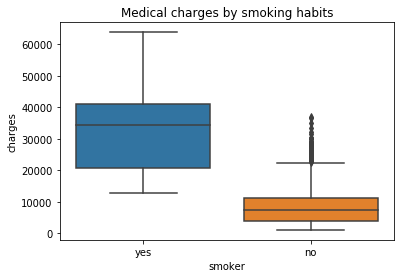

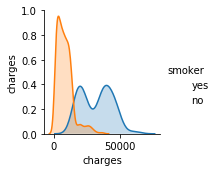

In [48]:
# Check visually if difference for smokers and non smokers is significant
sns.boxplot(x = "smoker", y = "charges", data = insurance_df)
plt.title('Medical charges by smoking habits')
plt.show()
sns.pairplot(insurance_df[['smoker','charges']],diag_kind='kde',hue='smoker')
#Both the plots indicate significant difference.Smokers have significantly higher charges

In [49]:
# Check statistically
#   H0: mu1 = mu3 (There is not significant difference between smokers and non smokers charges)
#   HA: mu1 Not= mu3 (There is significnt difference )

smoker = insurance_df[insurance_df["smoker"] == 'yes']['charges']
nonSmoker = insurance_df[insurance_df["smoker"] == 'no']['charges']

pvalue = ttest_ind(smoker, nonSmoker)
print(pvalue)

#pvalue is drastically less than 5% level of significance so the statistical decision is we reject the null hypothesis
# at 5% level of significance
# So there is sufficient evidence to prove that  there is a significant difference between charges of smoker and nonsmoker

# Hence, through EDA, visually as well as from statistical evidence, we can say there is significant difference between 
# medical costs billed by health insurance for smokers and non smokers

Ttest_indResult(statistic=46.664921172723716, pvalue=8.271435842177219e-283)


In [50]:
# 4b
# Does bmi of males differ significantly from that of  females?
#EDA to see difference , if any
insurance_df.groupby('sex')[['bmi']].describe()
# There is not much difference , as seen from mean and median

bmi                                                               
        count       mean       std     min     25%      50%       75%    max
sex                                                                         
female  662.0  30.377749  6.046023  16.815  26.125  30.1075  34.31375  48.07
male    676.0  30.943129  6.140435  15.960  26.410  30.6875  34.99250  53.13

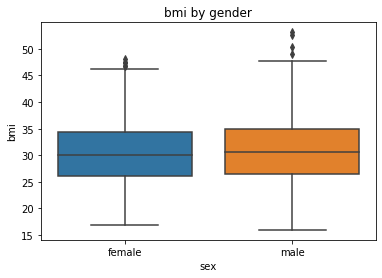

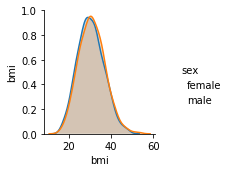

In [51]:
# Check visually if difference for smokers and non smokers is significant
sns.boxplot(x = "sex", y = "bmi", data = insurance_df)
plt.title('bmi by gender')
plt.show()
sns.pairplot(insurance_df[['sex','bmi']],diag_kind='kde',hue='sex')
#Both the plots indicate not much significant difference in bmi of males and females

In [52]:
# Check statistically
#   H0: mu1 = mu3 (There is not significant difference between male and female bmi)
#   HA: mu1 Not= mu3 (There is significant difference )

maleBMI = insurance_df[insurance_df["sex"] == 'male']['bmi']
femaleBMI = insurance_df[insurance_df["sex"] == 'female']['bmi']

pvalue = ttest_ind(maleBMI, femaleBMI)
print(pvalue)

#pvalue is more than 5% level of significance so the statistical decision is we fail to reject the null hypothesis
# at 5% level of significance
# So there is not sufficient evidence to prove that  there is a significant difference between bmi of males and females


# Hence, through EDA, visually as well as from statistical evidence, we can say that there is not significant
# difference in bmi of males and females

Ttest_indResult(statistic=1.696752635752224, pvalue=0.08997637178984932)


In [53]:
#4c  Is the proportion of smokers significantly different  in different genders?
#EDA
genderCounts = insurance_df.sex.value_counts()
#0 males and 1 females
totalMales = genderCounts[0]
totalFemales = genderCounts[1]
smokerMaleCounts = insurance_df[insurance_df["sex"] == 'male'].smoker.value_counts()[1]
smokerFemaleCounts = insurance_df[insurance_df["sex"] == 'female'].smoker.value_counts()[1]
print("Total male Smokers are ",smokerMaleCounts)
print("Total female Smokers are ",smokerFemaleCounts)

print("Total males  are ",totalMales)
print("Total females are ",totalFemales)

print("Proportion of male smokers are",round(smokerMaleCounts/totalMales, ndigits=2))
print("Proportion of female smokers are",round(smokerFemaleCounts/totalFemales, ndigits=2))

# Proportion of smokers in males are much higher than smokers in females but needs to be verified statistically if the
# two proportions are significantly different in population


# Hypothesis formulation
# H0 : proportion of smokers in males and females are same
# HA: proportions of smokers are significantly different in males and females

stat, pvalue = proportions_ztest([smokerFemaleCounts, smokerMaleCounts],[totalFemales, totalMales])
print(pvalue)

if (pvalue<0.05):
    print("Reject the null. Thus proportions of smokers are significantly different across gender")
else:
    print("Fail to reject the null. The proportions are not significantly different")

#pvalue is drastically less than 5% level of significance so the statistical decision is we reject the null hypothesis
# at 5% level of significance
# So there is sufficient evidence to prove that  there is a significant difference in proportions of smokers in males and females

Total male Smokers are  159
Total female Smokers are  115
Total males  are  676
Total females are  662
Proportion of male smokers are 0.24
Proportion of female smokers are 0.17
0.005324114164320532
Reject the null. Thus proportions of smokers are significantly different across gender


C:\Users\DELL\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  after removing the cwd from sys.path.
C:\Users\DELL\Anaconda3\lib\site-packages\ipykernel_launcher.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  """
C:\Users\DELL\Anaconda3\lib\site-packages\ipykernel_launcher.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  
C:\Users\DELL\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:487: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\Users\DELL\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


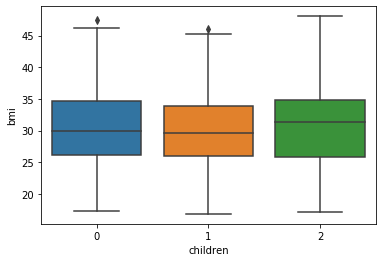

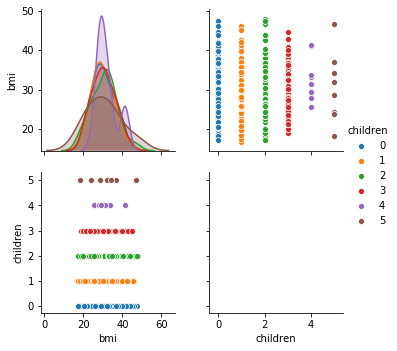

In [54]:
#4d Is the distribution of bmi across women with no  children, one child and two children, the same ? 
females_df = insurance_df[insurance_df['sex'] == 'female']

female_0kid_df =  females_df[insurance_df['children']==0]
female_1kid_df = females_df[insurance_df['children']==1]
female_2kid_df = females_df[insurance_df['children']==2]

final_df = pd.DataFrame()
final_df = final_df.append(female_0kid_df)
final_df = final_df.append(female_1kid_df)
final_df = final_df.append(female_2kid_df)

sns.boxplot(x='children',y='bmi', data=final_df)
#bmi distribution across females with 0, 1 and 2 kids donot vary much. In case of females with 1 kid, max bmi
#as well as third quartile is lss than the females with 0 and 2 kids. Median and max BMI of females with 2
# kids is little higher

sns.pairplot(females_df[['bmi','children']],diag_kind='kde',hue='children')

In [55]:
# spread of three groups seem to be almost similar from boxplots above. 
# Also distribution of BMI for females with different count of children are normal and overlap as well

# Let us preform levene test to see is if variance across groups is similar
# Precondition of equal variance is checked through Levene's Test
#LEVENE's TEST H0: Variances are equal
#LEVENE's TEST HA: Variances are not equal
from scipy.stats import levene

female_0kid_bmi_arr = female_0kid_df['bmi']
female_1kid_bmi_arr = female_1kid_df['bmi']
female_2kid_bmi_arr = female_2kid_df['bmi']

statistic,pvalue = levene(female_0kid_bmi_arr, female_1kid_bmi_arr, female_2kid_bmi_arr, center='mean') #For normal distribution center is mean
print(pvalue)

if (pvalue<0.05):
    print("Reject the null. Thus variances are not equal. ANOVA wont be reliable")
else:
    print("Fail to reject the null. The variances are equal across three groups holds true so ANOVA is reliable")
    
#pvalue is greater than alpha = 0.05 so we fail to reject the null so "variances are equal" holds true
#Thus ANOVA test is reliable


0.3865439704380632
Fail to reject the null. The variances are equal across three groups holds true so ANOVA is reliable


In [56]:
#Null Hypothesis H0:three groups have same population mean
#Alternate Hypothesis HA: At least one of the populations have different mean
from scipy.stats import f_oneway
statistic, pvalue = f_oneway(female_0kid_bmi_arr, female_1kid_bmi_arr, female_2kid_bmi_arr)
print("pvalue is ",pvalue)

if (pvalue<0.05):
    print("Reject the null. Thus at least one of the populations have different mean")
else:
    print("Fail to reject the null.Status quo of three groups having same population mean holds")
    
#pvalue is more than 5% level of significance so the statistical decision is we fail to reject the null hypothesis
# at 5% level of significance
# So there is not sufficient evidence to prove that  one of the population means is different  and
#status quo of three groups having same population mean is maintained 

pvalue is  0.7158579926754841
Fail to reject the null.Status quo of three groups having same population mean holds


In [1]:
# Hence distributon across three groups is same statistically as well as through visualizations

In [ ]:
#Conclusion:
# We anslysed the insurance data and there were some 